In [1]:
# Cell 1 — imports
import os
import re
import unicodedata
import numpy as np
import pandas as pd
import geopandas as gpd

from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable

rng = np.random.default_rng()

In [2]:
# Cell 2 — config
RESULTS_ROOT = "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/results"

TRAIN_PERCENT = 1
SEEDS = [1, 2, 3, 4, 5]

target_cols = ['va_ai', 'fol_ai', 'vb12_ai',
       'fe_ai', 'zn_ai',
  'avg_adult_education', 'log_exp']

ADM1_NAME_COL = "adm1name"


OUTDIR = os.path.join(RESULTS_ROOT, "evaluation")
os.makedirs(OUTDIR, exist_ok=True)

OUTCSV = os.path.join(OUTDIR, f"eval_adm1_seed_metrics_train_{TRAIN_PERCENT}.csv")
OUTCSV_MEAN = os.path.join(OUTDIR, f"eval_adm1_mean_target_train_{TRAIN_PERCENT}.csv")

OUTGPKG = os.path.join(OUTDIR, f"eval_adm1_seed_metrics_train_{TRAIN_PERCENT}.gpkg")
OUTGPKG_MEAN = os.path.join(OUTDIR, f"eval_adm1_mean_target_train_{TRAIN_PERCENT}.gpkg")

def seed_dir(seed: int) -> str:
    return os.path.join(RESULTS_ROOT, f"train_{TRAIN_PERCENT}_scaled", f"seed_{seed}_scaled")

def path_complete(seed: int) -> str:
    return os.path.join(seed_dir(seed), f"full_eth_scaled_train{TRAIN_PERCENT}_seed{seed}.csv")

def path_syn_scaled(seed: int) -> str:
    return os.path.join(seed_dir(seed), f"generated_pool_{TRAIN_PERCENT}_seed{seed}_scaled.csv")

def path_train_scaled(seed: int) -> str:
    return os.path.join(seed_dir(seed), f"train_subset_{TRAIN_PERCENT}_seed{seed}_scaled.csv")

In [3]:
# Cell 3 — helpers: keys + metrics + oversampling
def norm_place(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’","'").replace("‘","'").replace("`","'")
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = s.replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\bgovernorate\b", "", s).strip()
    return s


def _finite_1d(x):
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]


def emd_density_1d(x, y, bins=200, value_range=None, clip_quantiles=(0.0, 1.0)):
    """
    Approximate 1D Wasserstein-1 / EMD via densities on a common grid:
      W1 = ∫ |F(x) - G(x)| dx
    computed from histogram CDFs.

    - bins: number of histogram bins (higher = smoother but noisier with small n)
    - value_range: (min,max) shared range; if None, inferred from combined data
    - clip_quantiles: optionally clip tails when inferring range (e.g., (0.005, 0.995))
    """
    x = _finite_1d(x)
    y = _finite_1d(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan

    # Determine shared range
    if value_range is None:
        z = np.concatenate([x, y])
        qlo, qhi = clip_quantiles
        lo = np.quantile(z, qlo) if qlo > 0 else np.min(z)
        hi = np.quantile(z, qhi) if qhi < 1 else np.max(z)
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.min(z)), float(np.max(z))
        if hi <= lo:
            return 0.0
        value_range = (float(lo), float(hi))

    # Histogram densities with shared bins
    hx, edges = np.histogram(x, bins=bins, range=value_range, density=True)
    hy, _     = np.histogram(y, bins=edges, density=True)

    dx = np.diff(edges)  # bin widths

    # Convert density to probability mass per bin
    px = hx * dx
    py = hy * dx

    # CDFs on bins
    cdf_x = np.cumsum(px)
    cdf_y = np.cumsum(py)

    # ∫ |F-G| dx approximated as sum over bins of |CDF diff| * bin width
    w1 = np.sum(np.abs(cdf_x - cdf_y) * dx)

    return float(w1)

def abs_err_in_std(x_ref, x_est):
    x_ref = _finite_1d(x_ref)
    x_est = _finite_1d(x_est)
    if len(x_ref) == 0 or len(x_est) == 0:
        return np.nan
    sd = float(np.std(x_ref, ddof=0))
    if not np.isfinite(sd) or sd == 0.0:
        return np.nan
    return float(abs(np.mean(x_est) - np.mean(x_ref)) / sd)


def abs_err_in_std_across_adm1_means(x_ref, x_est, sd_across_adm1_means):
    """Standardized absolute mean error using SD of TRUE ADM1 means"""
    x_ref = _finite_1d(x_ref)
    x_est = _finite_1d(x_est)
    if len(x_ref) == 0 or len(x_est) == 0:
        return np.nan
    sd = float(sd_across_adm1_means)
    if not np.isfinite(sd) or sd == 0.0:
        return np.nan
    return float(abs(np.mean(x_est) - np.mean(x_ref)) / sd)

def _stable_int_hash(s: str) -> int:
    h = 2166136261
    for ch in str(s):
        h ^= ord(ch)
        h = (h * 16777619) & 0xFFFFFFFF
    return int(h)

UINT32_MAX = np.uint32(2**32 - 1)

def safe_seed(x) -> int:
    return int(x) & 0xFFFFFFFF

def bootstrap_oversample_1d(x, n, seed):
    x = _finite_1d(x)
    if n <= 0:
        return np.asarray([], dtype=float)
    if len(x) == 0:
        return np.asarray([], dtype=float)
    idx = rng.choice(np.arange(len(x)), size=n, replace=True)
    return x[idx]

In [4]:
# Cell 4 — load per seed
def load_seed_data(seed: int):
    comp = pd.read_csv(path_complete(seed))
    syn  = pd.read_csv(path_syn_scaled(seed))
    trn  = pd.read_csv(path_train_scaled(seed))

    need = [ADM1_NAME_COL] + target_cols
    for name, d in [("complete", comp), ("syn", syn), ("train", trn)]:
        missing = [c for c in need if c not in d.columns]
        if missing:
            raise ValueError(f"{name} missing columns: {missing}")

    for d in (comp, syn, trn):
        d[ADM1_NAME_COL] = d[ADM1_NAME_COL].astype(str)
        for c in target_cols:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    if ADM1_NAME_COL not in comp.columns:
        comp[ADM1_NAME_COL] = np.nan
    if ADM1_NAME_COL not in syn.columns:
        syn[ADM1_NAME_COL] = np.nan
    if ADM1_NAME_COL not in trn.columns:
        trn[ADM1_NAME_COL] = np.nan

    return comp, syn, trn

In [5]:
# Cell 5 — compute per seed/adm1/target metrics using density-based EMDs
rows = []

GEOM_CANDIDATES = ["adm1geometry", "geometryadm1", "geometry_adm1", "adm1_geom", "geom_adm1"]

def pick_geom_col(df):
    for c in GEOM_CANDIDATES:
        if c in df.columns:
            return c
    return None

BINS = 200
CLIP_Q = (0.0, 1.0)   # set to (0.005, 0.995) if you want to reduce tail sensitivity

for seed in SEEDS:
    comp, syn, trn = load_seed_data(seed)

    ADM1_GEOM_COL = pick_geom_col(comp)

    # Precompute a shared range per target (per seed) so all comparisons are on the same grid
    shared_range = {}
    for col in target_cols:
        z = np.concatenate([_finite_1d(comp[col].values), _finite_1d(trn[col].values)])
        if len(z) == 0:
            shared_range[col] = None
            continue
        lo = np.quantile(z, CLIP_Q[0]) if CLIP_Q[0] > 0 else float(np.min(z))
        hi = np.quantile(z, CLIP_Q[1]) if CLIP_Q[1] < 1 else float(np.max(z))
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.min(z)), float(np.max(z))
        shared_range[col] = (lo, hi) if hi > lo else None

    # SD of TRUE ADM1 means (per seed, per variable) for standardized mean error
    sd_across_adm1_means = {
        c: float(comp.groupby(ADM1_NAME_COL)[c].mean().std(ddof=0))
        for c in target_cols
    }

    adm1_values = sorted(comp[ADM1_NAME_COL].dropna().astype(str).unique().tolist())

    # NATIONAL TRUE distribution (comp, all adm1) for intrinsic metric
    # (same across adm1 for a given seed+target)
    comp_all = comp

    # NATIONAL baseline distribution (train subset, all adm1)
    trn_all = trn

    for adm1 in adm1_values:
        comp_a = comp.loc[comp[ADM1_NAME_COL] == adm1]
        syn_a  = syn.loc[syn[ADM1_NAME_COL] == adm1]

        # adm1 name and geometry (as stored in CSV)
        adm1_name = adm1
        adm1_geom = None
        if ADM1_GEOM_COL is not None and len(comp_a):
            adm1_geom = comp_a[ADM1_GEOM_COL].iloc[0]

        for t_i, col in enumerate(target_cols):
            x_true_adm1 = comp_a[col].values                    # TRUE adm1
            x_gen_adm1  = syn_a[col].values                     # GEN adm1
            x_nat_trn   = trn_all[col].values                   # NATIONAL baseline = full train subset (all adm1)
            x_true_nat  = comp_all[col].values                  # NATIONAL true = full comp (all adm1)

            n_true = int(np.isfinite(x_true_adm1).sum())
            n_gen  = int(np.isfinite(x_gen_adm1).sum())
            n_nat  = int(np.isfinite(x_nat_trn).sum())

            if n_true == 0:
                continue

            # Oversampling baseline = bootstrap from TRAIN within same adm1 to size n_true
            x_trn_adm1 = trn_all.loc[trn_all[ADM1_NAME_COL] == adm1, col].values
            over_seed = safe_seed((seed * 1_000_000) + (_stable_int_hash(adm1) * 1_000) + (t_i + 1))
            x_over = bootstrap_oversample_1d(x_trn_adm1, n_true, over_seed)

            vr = shared_range[col]

            rows.append(
                dict(
                    seed=seed,
                    adm1_code=adm1,
                    adm1_name=adm1_name,
                    adm1geometry=adm1_geom,   # stays whatever string/object is in your CSV (often WKT)
                    target=col,

                    n_true=n_true,
                    n_gen=n_gen,
                    n_nat=n_nat,
                    n_over=n_true,

                    # Density-based EMDs
                    emd_gen=emd_density_1d(x_true_adm1, x_gen_adm1, bins=BINS, value_range=vr, clip_quantiles=CLIP_Q),
                    emd_nat=emd_density_1d(x_true_adm1, x_nat_trn,  bins=BINS, value_range=vr, clip_quantiles=CLIP_Q),
                    emd_over=emd_density_1d(x_true_adm1, x_over,    bins=BINS, value_range=vr, clip_quantiles=CLIP_Q),

                    # Intrinsic (your definition): TRUE adm1 vs TRUE national (comp all)
                    variability_intrinsic=emd_density_1d(x_true_adm1, x_true_nat, bins=BINS, value_range=vr, clip_quantiles=CLIP_Q),

                    # Mean errors standardized by SD of TRUE adm1 means
                    absmeanerr_gen=abs_err_in_std_across_adm1_means(x_true_adm1, x_gen_adm1, sd_across_adm1_means[col]),
                    absmeanerr_nat=abs_err_in_std_across_adm1_means(x_true_adm1, x_nat_trn,  sd_across_adm1_means[col]),
                    absmeanerr_over=abs_err_in_std_across_adm1_means(x_true_adm1, x_over,    sd_across_adm1_means[col]),
                )
            )

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(OUTCSV, index=False)
metrics_df.head()

,seed,adm1_code,adm1_name,adm1geometry,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over
0,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",va_ai,782,782,131,782,0.312715,0.181812,0.573502,0.214577,0.626827,0.488111,1.343153
1,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",fol_ai,782,782,131,782,0.373447,0.412934,0.431995,0.112310,1.019866,1.203967,1.220185
2,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",vb12_ai,782,782,131,782,0.782882,0.108193,0.776958,0.180890,3.232597,0.046733,3.216901
3,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",fe_ai,782,782,131,782,0.115920,0.243963,0.295186,0.215984,0.075906,0.695226,0.362043
4,1,Addis Ababa,Addis Ababa,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",zn_ai,782,782,131,782,0.227432,0.369971,0.361153,0.207562,0.229555,1.063611,0.420646


## Visualize

In [6]:
# Cell 10 — mean over seeds per ADM1+target (map-ready)
mean_df = metrics_df.groupby(["adm1_code", "adm1_name", "target",'adm1geometry'], dropna=False).agg(
    emd_gen=("emd_gen", "mean"),
    emd_nat=("emd_nat", "mean"),
    emd_over=("emd_over", "mean"),
    abs_gen=("absmeanerr_gen", "mean"),
    abs_nat=("absmeanerr_nat", "mean"),
    abs_over=("absmeanerr_over", "mean"),
    variability_intrinsic=("variability_intrinsic", "mean"),
).reset_index()

mean_df["imp_emd_nat"]  = mean_df["emd_nat"]  - mean_df["emd_gen"]
mean_df["imp_emd_over"] = mean_df["emd_over"] - mean_df["emd_gen"]
mean_df["imp_abs_nat"]  = mean_df["abs_nat"]  - mean_df["abs_gen"]
mean_df["imp_abs_over"] = mean_df["abs_over"] - mean_df["abs_gen"]

mean_df.head()

,adm1_code,adm1_name,target,adm1geometry,emd_gen,emd_nat,emd_over,abs_gen,abs_nat,abs_over,variability_intrinsic,imp_emd_nat,imp_emd_over,imp_abs_nat,imp_abs_over
0,Addis Ababa,Addis Ababa,avg_adult_education,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",0.184123,0.774883,0.354541,0.281076,2.127490,0.681358,0.668366,0.590759,0.170418,1.846414,0.400282
1,Addis Ababa,Addis Ababa,fe_ai,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",0.346497,0.230833,0.579000,0.666400,0.292243,1.203997,0.258038,-0.115664,0.232503,-0.374156,0.537598
2,Addis Ababa,Addis Ababa,fol_ai,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",0.522871,0.308993,0.669080,0.983125,0.642937,1.398538,0.143477,-0.213879,0.146209,-0.340188,0.415413
3,Addis Ababa,Addis Ababa,log_exp,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",0.234002,0.825422,0.263051,0.456924,2.470215,0.556471,0.781691,0.591420,0.029050,2.013292,0.099548
4,Addis Ababa,Addis Ababa,va_ai,"POLYGON ((38.6582 9.0146, 38.6594 8.9806, 38.6...",0.722027,0.575250,0.831135,1.131230,0.816005,1.319158,0.320018,-0.146776,0.109109,-0.315225,0.187928


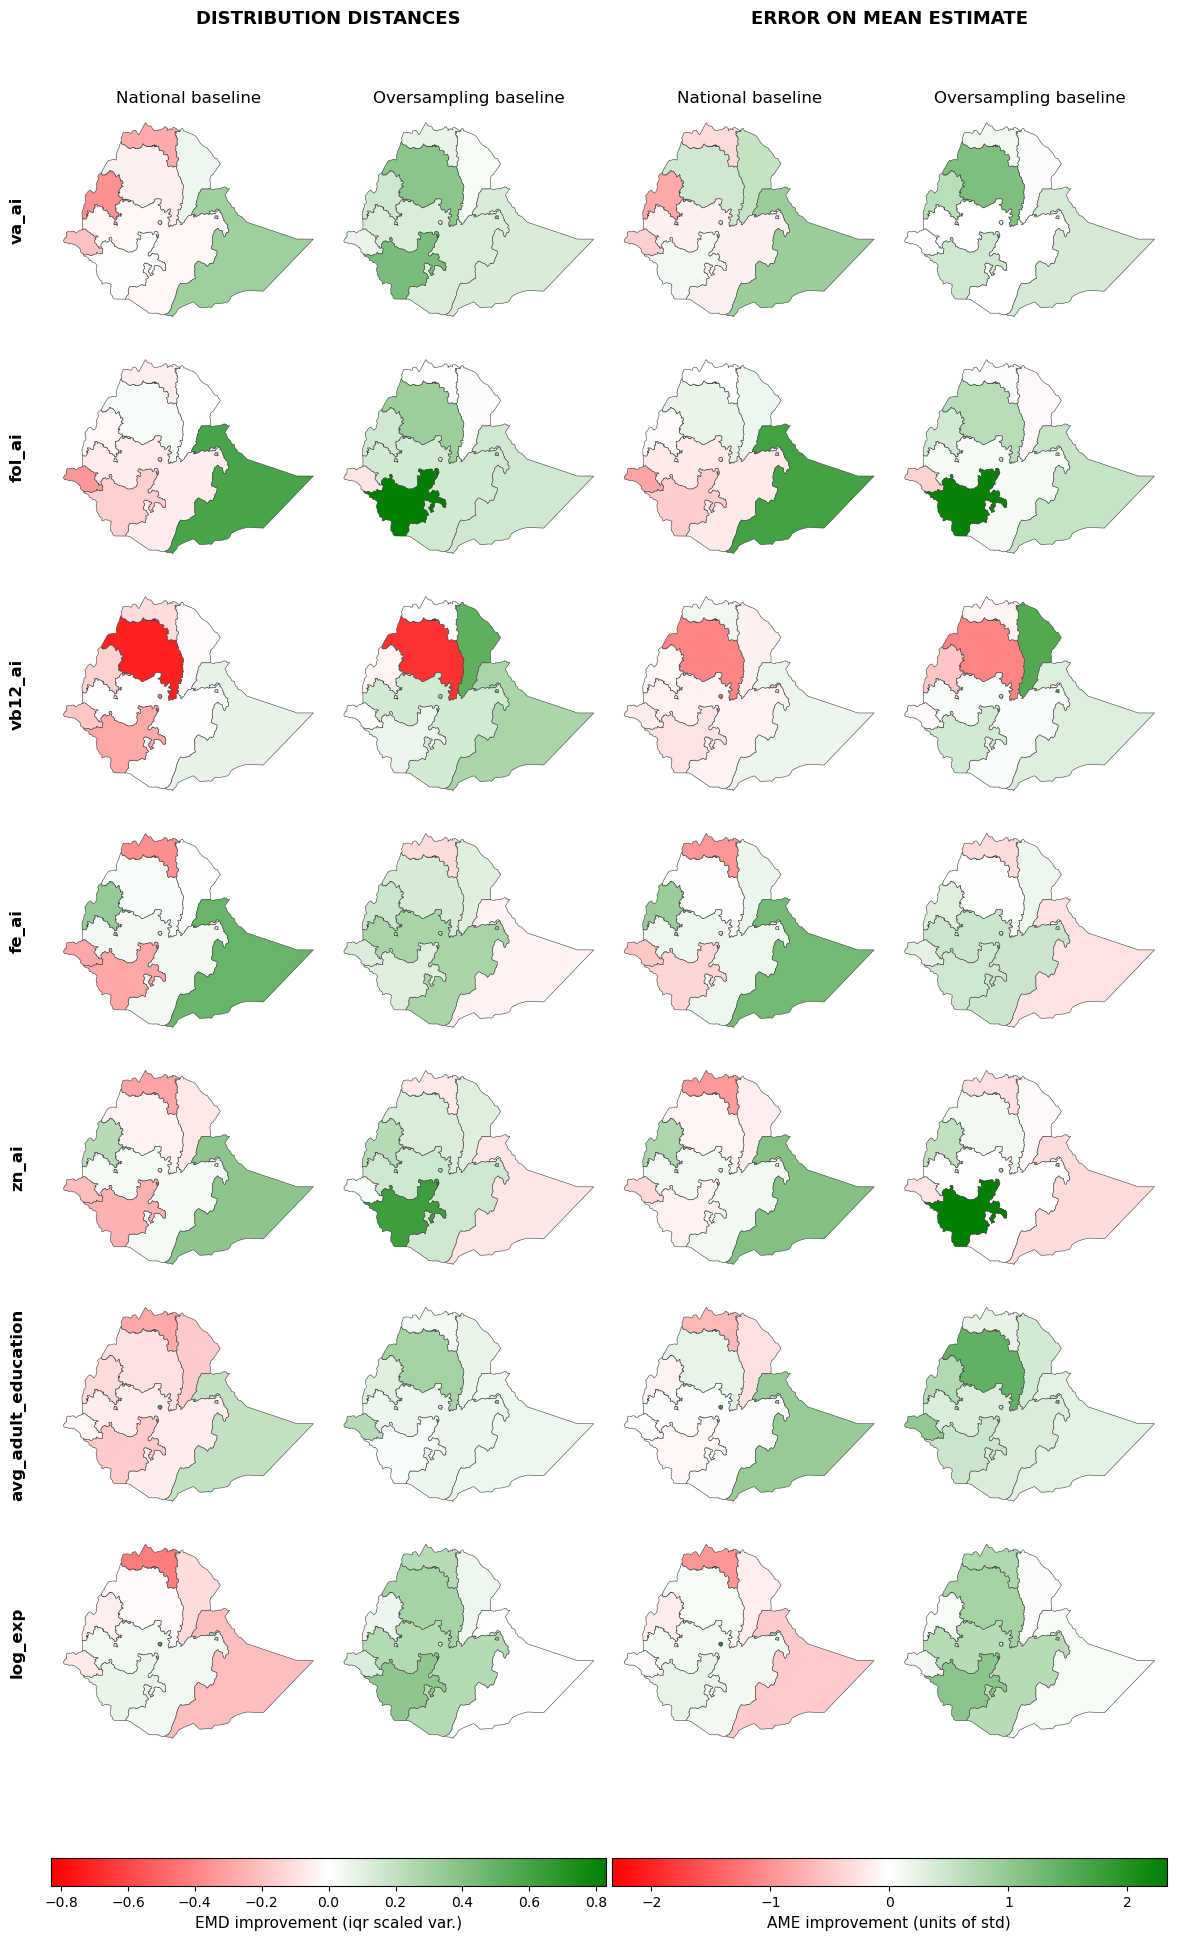

In [7]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from shapely import wkt

GEOM_COL = "adm1geometry"  # your geometry column name

# --- 1) attach geometry to mean_df, without creating _x/_y duplicates ---
mean_df2 = mean_df.copy()
if GEOM_COL in mean_df2.columns:
    mean_df2 = mean_df2.drop(columns=[GEOM_COL])

geom_df = (metrics_df[["adm1_code", GEOM_COL]]
           .dropna(subset=[GEOM_COL])
           .drop_duplicates(subset=["adm1_code"])
           .reset_index(drop=True))

mean_df2 = mean_df2.merge(geom_df, on="adm1_code", how="left")

# --- 2) convert to GeoDataFrame (handles both WKT strings and shapely geometries) ---
def _to_geom(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return None
    if hasattr(val, "geom_type"):  # already shapely
        return val
    if isinstance(val, str) and val.strip():
        try:
            return wkt.loads(val)
        except Exception:
            return None
    return None

mean_df2[GEOM_COL] = mean_df2[GEOM_COL].apply(_to_geom)

mean_gdf = gpd.GeoDataFrame(mean_df2, geometry=GEOM_COL, crs="EPSG:4326")  # adjust CRS if needed
mean_gdf[GEOM_COL] = mean_gdf[GEOM_COL].buffer(0)  # fix invalid geometries

# --- 3) paper-ready plot grid (group headers, your red-white-green cmap, consistent norms) ---

# keep your red/white/green map
cmap = LinearSegmentedColormap.from_list("rwg", ["red", "white", "green"])

emd_cols = ["imp_emd_nat", "imp_emd_over"]
abs_cols = ["imp_abs_nat", "imp_abs_over"]

col_specs = [
    ("imp_emd_nat",  "National baseline",      "emd"),
    ("imp_emd_over", "Oversampling baseline",  "emd"),
    ("imp_abs_nat",  "National baseline",      "abs"),
    ("imp_abs_over", "Oversampling baseline",  "abs"),
]

def _maxabs(df, cols):
    v = df[cols].to_numpy().ravel()
    v = v[np.isfinite(v)]
    return float(np.nanmax(np.abs(v))) if len(v) else 1.0

v_emd = _maxabs(mean_gdf, emd_cols)
v_abs = _maxabs(mean_gdf, abs_cols)

norm_emd = TwoSlopeNorm(vmin=-v_emd, vcenter=0.0, vmax=v_emd)
norm_abs = TwoSlopeNorm(vmin=-v_abs, vcenter=0.0, vmax=v_abs)

nrows = len(target_cols)
ncols = 4

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(3.6*ncols, 3.4*nrows),
    constrained_layout=False
)
if nrows == 1:
    axes = np.array([axes])

# --- Column titles (2nd-level headers) ---
for j, (_, col_title, _) in enumerate(col_specs):
    axes[0, j].set_title(col_title, fontsize=12,  pad=8)

# --- Group titles (top-level headers spanning columns) ---
# Make room at the top for the group headers
plt.subplots_adjust(top=0.88, wspace=0.02, hspace=0.04)

# Compute centers of the left group (cols 0-1) and right group (cols 2-3)
# Use axes positions so it adapts to any figsize/layout.
pos00 = axes[0, 0].get_position()
pos01 = axes[0, 1].get_position()
pos02 = axes[0, 2].get_position()
pos03 = axes[0, 3].get_position()

left_center_x  = (pos00.x0 + pos01.x1) / 2
right_center_x = (pos02.x0 + pos03.x1) / 2
group_y = max(pos00.y1, pos01.y1, pos02.y1, pos03.y1) + 0.03

fig.text(left_center_x, group_y, "DISTRIBUTION DISTANCES",
         ha="center", va="bottom", fontsize=13, fontweight="bold")
fig.text(right_center_x, group_y, "ERROR ON MEAN ESTIMATE",
         ha="center", va="bottom", fontsize=13, fontweight="bold")

# --- Draw maps ---
for i, t in enumerate(target_cols):
    g = mean_gdf.loc[mean_gdf["target"] == t].copy()

    # Row label on the left (feature name)
    axes[i, 0].annotate(
        t, xy=(0, 0.5), xycoords="axes fraction",
        xytext=(-18, 0), textcoords="offset points",
        ha="right", va="center",
        fontsize=12, fontweight="bold", rotation=90
    )

    for j, (col, _, kind) in enumerate(col_specs):
        ax = axes[i, j]
        norm = norm_emd if kind == "emd" else norm_abs

        g.plot(
            column=col,
            cmap=cmap,
            norm=norm,
            ax=ax,
            linewidth=0.4,
            edgecolor="0.25",
            missing_kwds={"color": "0.9"},
        )
        ax.set_axis_off()

# --- Colorbars: one per metric group ---
sm_emd = ScalarMappable(norm=norm_emd, cmap=cmap); sm_emd.set_array([])
sm_abs = ScalarMappable(norm=norm_abs, cmap=cmap); sm_abs.set_array([])

cb1 = fig.colorbar(sm_emd, ax=axes[:, :2], orientation="horizontal", fraction=0.04, pad=0.06)
cb1.set_label("EMD improvement (iqr scaled var.)", fontsize=11)
cb1.ax.tick_params(labelsize=10)

cb2 = fig.colorbar(sm_abs, ax=axes[:, 2:], orientation="horizontal", fraction=0.04, pad=0.06)
cb2.set_label("AME improvement (units of std)", fontsize=11)
cb2.ax.tick_params(labelsize=10)

# --- Save exactly where you want ---
fig.savefig(
    "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/results/evaluation/improvement_maps.pdf",
    bbox_inches="tight"
)

plt.show()

## summary

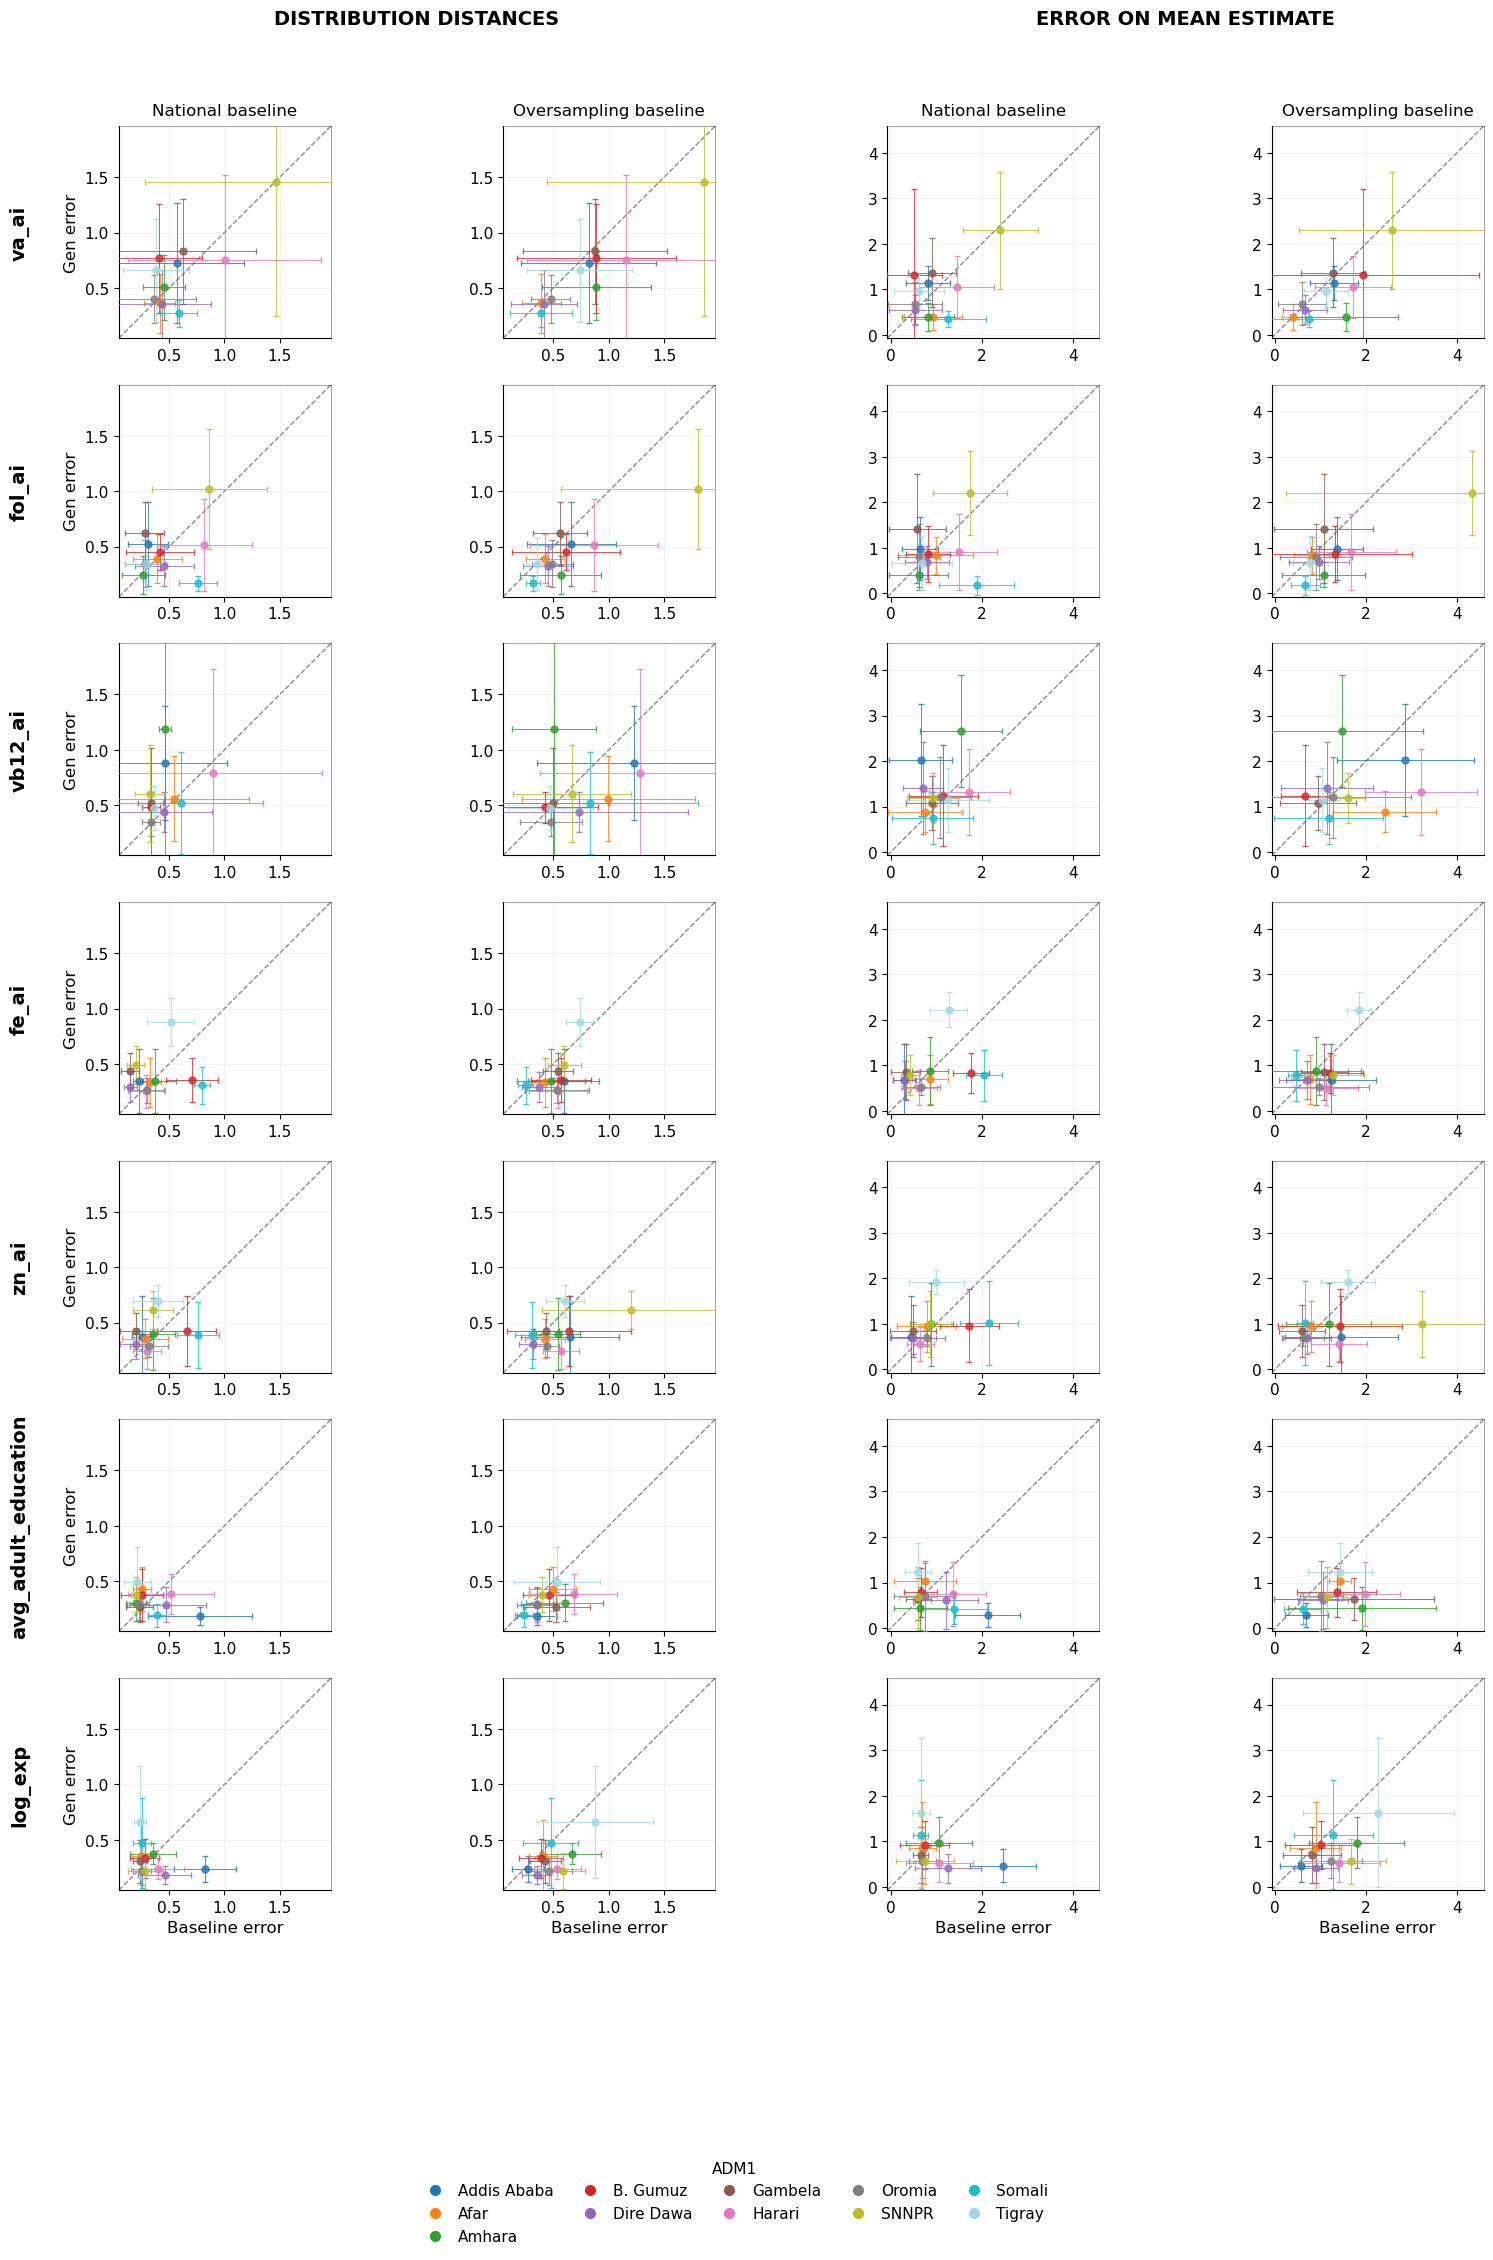

In [ ]:
# Cell — same layout, but:
# - legend centered below (no box)
# - variable names as row labels OUTSIDE the axes
# - "Gen error" / "Baseline error" not bold
# - "National baseline" / "Oversampling baseline" not bold

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

region_col = "adm1_name"
if region_col not in metrics_df.columns or metrics_df[region_col].isna().all():
    region_col = "adm1_code"

regions = (
    metrics_df[[region_col]]
    .dropna()
    .astype(str)[region_col]
    .unique()
    .tolist()
)
regions = sorted(regions)

cmap = plt.get_cmap("tab20", max(len(regions), 1))
region2color = {r: cmap(i) for i, r in enumerate(regions)}

# aggregate over seeds
agg = (
    metrics_df
    .assign(_region=metrics_df[region_col].astype(str))
    .groupby(["_region", "target"], dropna=False)
    .agg(
        emd_gen_mean=("emd_gen","mean"),
        emd_gen_std=("emd_gen","std"),
        emd_nat_mean=("emd_nat","mean"),
        emd_nat_std=("emd_nat","std"),
        emd_over_mean=("emd_over","mean"),
        emd_over_std=("emd_over","std"),
        absmeanerr_gen_mean=("absmeanerr_gen","mean"),
        absmeanerr_gen_std=("absmeanerr_gen","std"),
        absmeanerr_nat_mean=("absmeanerr_nat","mean"),
        absmeanerr_nat_std=("absmeanerr_nat","std"),
        absmeanerr_over_mean=("absmeanerr_over","mean"),
        absmeanerr_over_std=("absmeanerr_over","std"),
    )
    .reset_index()
)

def _finite(x):
    x = np.asarray(x).ravel()
    return x[np.isfinite(x)]

def _pad_limits(lo, hi, frac=0.06):
    if not np.isfinite(lo) or not np.isfinite(hi):
        return (0.0, 1.0)
    if hi <= lo:
        hi = lo + 1.0
    pad = (hi - lo) * frac
    return lo - pad, hi + pad

# fixed limits within blocks (global)
emd_vals = np.concatenate([
    _finite(agg["emd_nat_mean"].to_numpy()),
    _finite(agg["emd_over_mean"].to_numpy()),
    _finite(agg["emd_gen_mean"].to_numpy()),
])
emd_lo, emd_hi = (float(np.min(emd_vals)), float(np.max(emd_vals))) if len(emd_vals) else (0.0, 1.0)
emd_lo, emd_hi = _pad_limits(emd_lo, emd_hi)

abs_vals = np.concatenate([
    _finite(agg["absmeanerr_nat_mean"].to_numpy()),
    _finite(agg["absmeanerr_over_mean"].to_numpy()),
    _finite(agg["absmeanerr_gen_mean"].to_numpy()),
])
abs_lo, abs_hi = (float(np.min(abs_vals)), float(np.max(abs_vals))) if len(abs_vals) else (0.0, 1.0)
abs_lo, abs_hi = _pad_limits(abs_lo, abs_hi)

col_specs = [
    ("emd_nat",         "emd_gen",         "National baseline",     "emd"),
    ("emd_over",        "emd_gen",         "Oversampling baseline", "emd"),
    ("absmeanerr_nat",  "absmeanerr_gen",  "National baseline",     "abs"),
    ("absmeanerr_over", "absmeanerr_gen",  "Oversampling baseline", "abs"),
]

nrows = len(target_cols)
ncols = 4

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "normal",   # not bold for per-column titles
    "axes.labelsize": 12,
    "axes.labelweight": "normal",   # not bold for axis labels
    "legend.fontsize": 11,
})

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.2*ncols, 3.5*nrows),
    sharex=False, sharey=False
)
if nrows == 1:
    axes = np.array([axes])

# More left margin for external row labels, more bottom margin for legend
fig.subplots_adjust(top=0.88, left=0.10, right=0.98, bottom=0.16, wspace=0.18, hspace=0.22)

# Column subheaders (NOT bold)
for j, (_, _, subhead, _) in enumerate(col_specs):
    axes[0, j].set_title(subhead, pad=8, fontweight="normal")

# Group headers spanning columns 0–1 and 2–3 (keep bold like the map figure)
pos0 = axes[0, 0].get_position()
pos1 = axes[0, 1].get_position()
pos2 = axes[0, 2].get_position()
pos3 = axes[0, 3].get_position()
left_center_x  = (pos0.x0 + pos1.x1) / 2
right_center_x = (pos2.x0 + pos3.x1) / 2
group_y = max(pos0.y1, pos1.y1, pos2.y1, pos3.y1) + 0.04

fig.text(left_center_x, group_y, "DISTRIBUTION DISTANCES",
         ha="center", va="bottom", fontsize=14, fontweight="bold")
fig.text(right_center_x, group_y, "ERROR ON MEAN ESTIMATE",
         ha="center", va="bottom", fontsize=14, fontweight="bold")

# Draw panels
for i, t in enumerate(target_cols):
    a = agg.loc[agg["target"] == t].copy()

    # external row label (variable name) using figure coords
    bb = axes[i, 0].get_position()
    y_center = (bb.y0 + bb.y1) / 2
    fig.text(0.075, y_center, t, rotation=90, ha="center", va="center",
             fontsize=14, fontweight="bold")  # variable names outside, can stay bold

    for j, (xbase, ygen, _, kind) in enumerate(col_specs):
        ax = axes[i, j]

        for reg in regions:
            sub = a.loc[a["_region"] == reg]
            if sub.empty:
                continue

            x = float(sub[f"{xbase}_mean"].iloc[0])
            y = float(sub[f"{ygen}_mean"].iloc[0])

            xstd = sub[f"{xbase}_std"].iloc[0]
            ystd = sub[f"{ygen}_std"].iloc[0]
            xerr = float(xstd) if np.isfinite(xstd) else 0.0
            yerr = float(ystd) if np.isfinite(ystd) else 0.0

            ax.errorbar(
                x, y,
                xerr=xerr, yerr=yerr,
                fmt="o",
                markersize=5,
                elinewidth=0.7,
                capsize=2,
                color=region2color[reg],
                ecolor=region2color[reg],
                alpha=0.80,
                zorder=3,
            )

        # fixed limits within block + y=x + equal aspect
        lo, hi = (emd_lo, emd_hi) if kind == "emd" else (abs_lo, abs_hi)
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0, color="0.55", zorder=2)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        ax.grid(True, linewidth=0.5, alpha=0.22, zorder=1)
        ax.spines["top"].set_alpha(0.35)
        ax.spines["right"].set_alpha(0.35)

        # axis labels (NOT bold)
        if i == nrows - 1:
            ax.set_xlabel("Baseline error", fontweight="normal")
        if j == 0:
            ax.set_ylabel("Gen error", fontweight="normal")

# Legend: below, centered, no frame/box
handles = [
    Line2D([0], [0], marker="o", linestyle="None",
           markersize=7, color=region2color[reg], label=reg)
    for reg in regions
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(5, max(1, len(regions))),  # wrap nicely
    title="ADM1",
    frameon=False,
    columnspacing=1.4,
    handletextpad=0.5,

)

fig.savefig(
    "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/results/evaluation/err_comparison.pdf",
    bbox_inches="tight"
)

plt.show()



## Visualize distributions

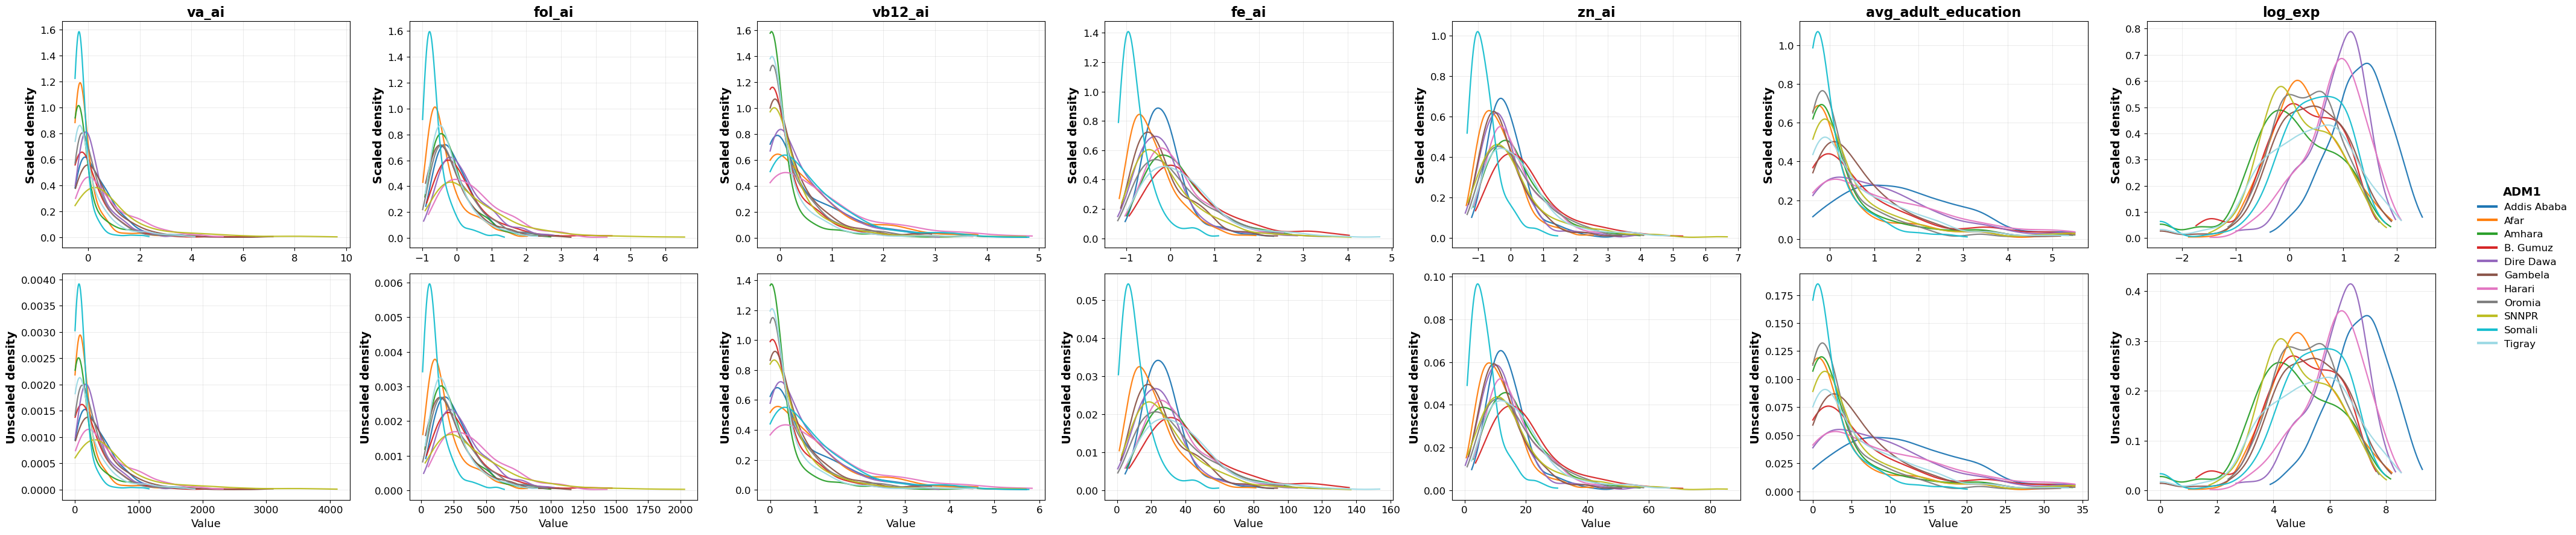

In [ ]:
# Cell — ADM1 density plots (scaled vs unscaled): bigger fonts + bold titles + ONE shared ADM1 legend
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

UNSCALED_COMPLETE_PATH = "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/full.csv"

region_col = "adm1_name"

regions = (
    metrics_df[[region_col]]
    .dropna()
    .astype(str)[region_col]
    .unique()
    .tolist()
)
regions = sorted(regions)

cmap = plt.get_cmap("tab20", max(len(regions), 1))
region2color = {r: cmap(i) for i, r in enumerate(regions)}

seed_for_scaled = SEEDS[0]
comp_scaled = pd.read_csv(path_complete(seed_for_scaled))
comp_unscaled = pd.read_csv(UNSCALED_COMPLETE_PATH)

for d in (comp_scaled, comp_unscaled):
    d[ADM1_NAME_COL] = d[ADM1_NAME_COL].astype(str)
    for c in target_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")

if ADM1_NAME_COL not in comp_scaled.columns:
    comp_scaled[ADM1_NAME_COL] = comp_scaled[ADM1_NAME_COL].astype(str)
if ADM1_NAME_COL not in comp_unscaled.columns:
    comp_unscaled[ADM1_NAME_COL] = comp_unscaled[ADM1_NAME_COL].astype(str)

if region_col == "adm1_name":
    comp_scaled["_region"] = comp_scaled[ADM1_NAME_COL].astype(str)
    comp_unscaled["_region"] = comp_unscaled[ADM1_NAME_COL].astype(str)
else:
    comp_scaled["_region"] = comp_scaled[ADM1_NAME_COL].astype(str)
    comp_unscaled["_region"] = comp_unscaled[ADM1_NAME_COL].astype(str)

def _kde_xy(x, n=300):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 5:
        return None, None
    lo, hi = np.quantile(x, [0.01, 0.99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = float(np.min(x)), float(np.max(x))
    if lo == hi:
        lo -= 1.0
        hi += 1.0
    xs = np.linspace(lo, hi, n)
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(x)
        ys = kde(xs)
        return xs, ys
    except Exception:
        hist, edges = np.histogram(x, bins=60, density=True)
        mids = 0.5 * (edges[:-1] + edges[1:])
        return mids, hist

ncols = len(target_cols)
fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(5.8*ncols, 9.0), sharex=False, sharey=False)
if ncols == 1:
    axes = axes.reshape(2, 1)

for c, t in enumerate(target_cols):
    ax_scaled = axes[0, c]
    ax_unsc  = axes[1, c]

    ax_scaled.set_title(t, fontsize=16, fontweight="bold")

    for reg in regions:
        xs, ys = _kde_xy(comp_scaled.loc[comp_scaled["_region"] == reg, t].values)
        if xs is not None:
            ax_scaled.plot(xs, ys, color=region2color[reg], linewidth=1.6, alpha=0.95)

        xs2, ys2 = _kde_xy(comp_unscaled.loc[comp_unscaled["_region"] == reg, t].values)
        if xs2 is not None:
            ax_unsc.plot(xs2, ys2, color=region2color[reg], linewidth=1.6, alpha=0.95)

    ax_scaled.set_ylabel("Scaled density", fontsize=14, fontweight="bold")
    ax_unsc.set_ylabel("Unscaled density", fontsize=14, fontweight="bold")
    ax_unsc.set_xlabel("Value", fontsize=13)

    ax_scaled.tick_params(axis="both", labelsize=12)
    ax_unsc.tick_params(axis="both", labelsize=12)

    ax_scaled.grid(True, linewidth=0.5, alpha=0.35)
    ax_unsc.grid(True, linewidth=0.5, alpha=0.35)

# one shared legend for ADM1 colors (right side)
handles = [
    Line2D([0], [0], color=region2color[r], lw=3, label=str(r))
    for r in regions
]
leg = fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="ADM1",
)
plt.setp(leg.get_title(), fontsize=14, fontweight="bold")
for txt in leg.get_texts():
    txt.set_fontsize(12)

plt.tight_layout()
plt.show()

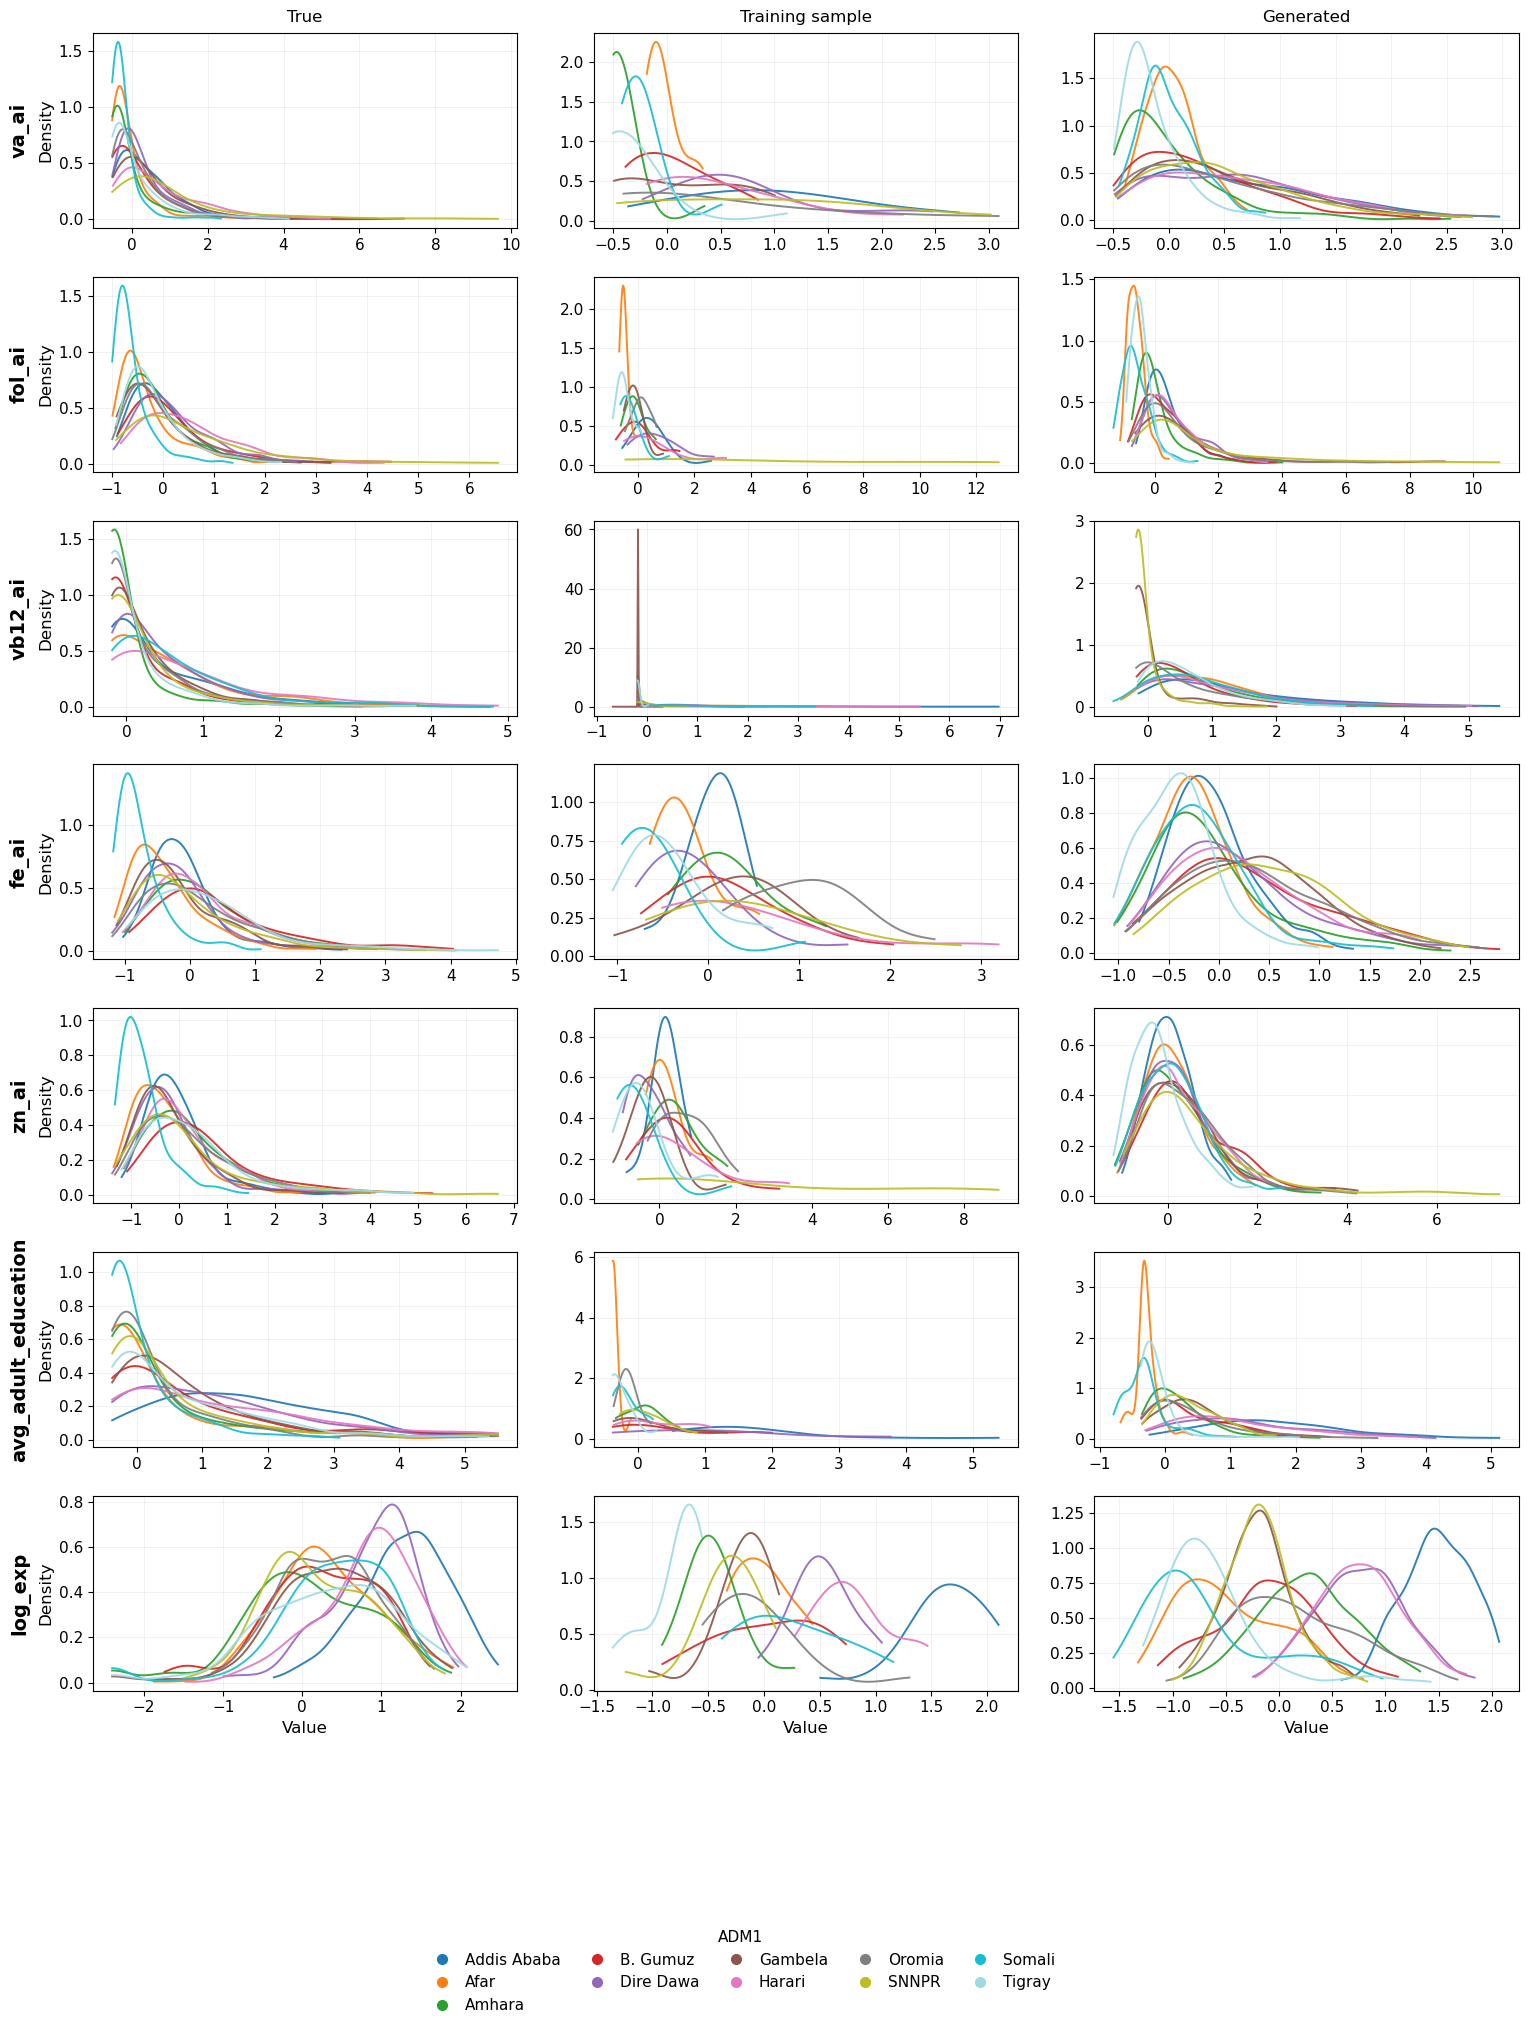

In [ ]:
# Cell — ADM1 density plots (UNSCALED): rows=variables, cols=3 (true / generated / oversampled)
# Legend style matches your scatter figure: centered below, no box, title "ADM1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- paths (edit if yours differ) ----
UNSCALED_TRUE_PATH       = path_complete(SEEDS[0])
UNSCALED_GENERATED_PATH  = path_syn_scaled(SEEDS[0])   
UNSCALED_OVERSAMPLED_PATH = path_train_scaled(SEEDS[0])

region_col = "adm1_name"

# regions + consistent colors
regions = (
    metrics_df[[region_col]]
    .dropna()
    .astype(str)[region_col]
    .unique()
    .tolist()
)
regions = sorted(regions)

cmap = plt.get_cmap("tab20", max(len(regions), 1))
region2color = {r: cmap(i) for i, r in enumerate(regions)}

# load
df_true = pd.read_csv(UNSCALED_TRUE_PATH)
df_gen  = pd.read_csv(UNSCALED_GENERATED_PATH)
df_over = pd.read_csv(UNSCALED_OVERSAMPLED_PATH) if UNSCALED_OVERSAMPLED_PATH else None

def _prep(d):
    d = d.copy()
    d[ADM1_NAME_COL] = d[ADM1_NAME_COL].astype(str)
    for c in target_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["_region"] = d[ADM1_NAME_COL].astype(str)
    return d

df_true = _prep(df_true)
df_gen  = _prep(df_gen)
if df_over is not None:
    df_over = _prep(df_over)

def _kde_xy(x, n=300):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 5:
        return None, None
    lo, hi = np.quantile(x, [0.01, 0.99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = float(np.min(x)), float(np.max(x))
    if lo == hi:
        lo -= 1.0
        hi += 1.0
    xs = np.linspace(lo, hi, n)
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(x)
        ys = kde(xs)
        return xs, ys
    except Exception:
        hist, edges = np.histogram(x, bins=60, density=True)
        mids = 0.5 * (edges[:-1] + edges[1:])
        return mids, hist

# layout: rows=variables, cols=3 datasets
row_vars = list(target_cols)
col_sets = [
    ("True",      df_true),
    ("Training sample", df_over),
    ("Generated", df_gen),
]
# drop oversampled column if you haven't set the path yet
col_sets = [(name, d) for name, d in col_sets if d is not None]

nrows = len(row_vars)
ncols = len(col_sets)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "axes.labelsize": 12,
    "axes.labelweight": "normal",
})

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5.4*ncols, 3.2*nrows),
    sharex=False, sharey=False
)
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes.reshape(1, ncols)
elif ncols == 1:
    axes = axes.reshape(nrows, 1)

# space for row labels + legend below
fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.16, wspace=0.18, hspace=0.25)

# column titles
for j, (title, _) in enumerate(col_sets):
    axes[0, j].set_title(title, pad=8, fontweight="normal")

for i, var in enumerate(row_vars):
    # row label outside, like your scatter grid
    bb = axes[i, 0].get_position()
    y_center = (bb.y0 + bb.y1) / 2
    fig.text(0.055, y_center, var, rotation=90, ha="center", va="center",
             fontsize=14, fontweight="bold")

    for j, (_, dset) in enumerate(col_sets):
        ax = axes[i, j]

        # plot KDE per ADM1
        for reg in regions:
            xs, ys = _kde_xy(dset.loc[dset["_region"] == reg, var].values)
            if xs is not None:
                ax.plot(xs, ys, color=region2color[reg], linewidth=1.4, alpha=0.92)

        # cosmetics
        ax.grid(True, linewidth=0.5, alpha=0.25)
        ax.tick_params(axis="both", labelsize=11)

        # only bottom row gets x label
        if i == nrows - 1:
            ax.set_xlabel("Value")
        # only first column gets y label
        if j == 0:
            ax.set_ylabel("Density")

# legend identical style to your scatter plot: bottom-centered, no box
handles = [
    Line2D([0], [0], marker="o", linestyle="None",
           markersize=7, color=region2color[reg], label=reg)
    for reg in regions
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(5, max(1, len(regions))),
    title="ADM1",
    frameon=False,
    columnspacing=1.4,
    handletextpad=0.5,
)

fig.savefig(
    "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/results/evaluation/distributions.pdf",
    bbox_inches="tight"
)

plt.show()

## EMD vs intrinsic variability

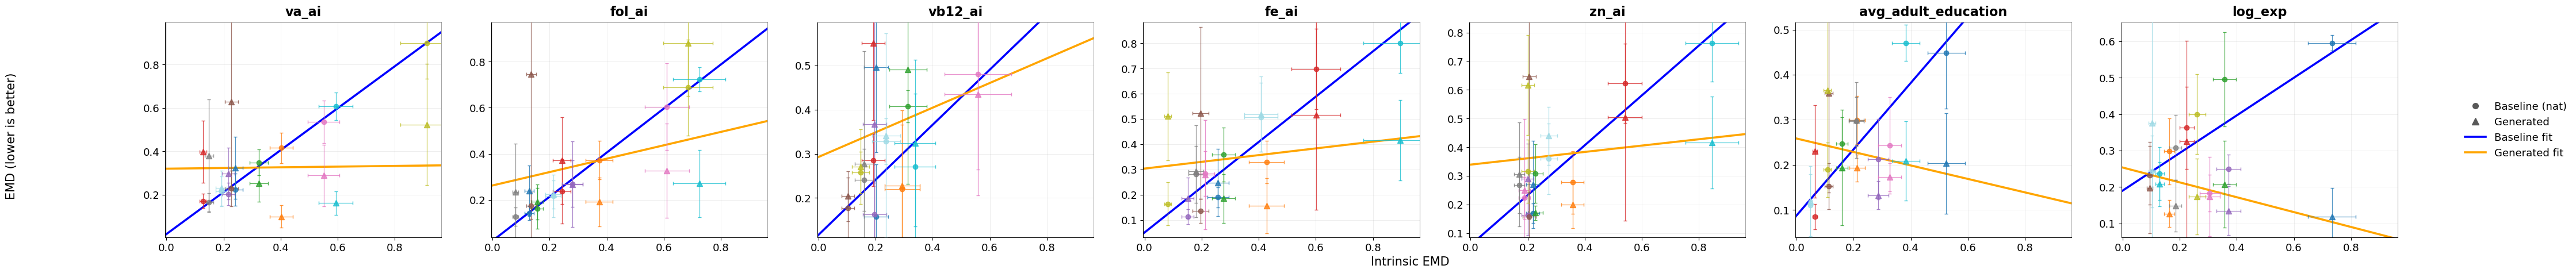

In [ ]:
# Cell — prettier / paper-ready: larger fonts, cleaner spacing, consistent style, better legend placement
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from scipy.stats import linregress
except Exception:
    linregress = None

# -------------------------
# Config: typography & style
# -------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "normal",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# -------------------------
# Region col + colors
# -------------------------
region_col = "adm1_name"
if region_col not in metrics_df.columns or metrics_df[region_col].isna().all():
    region_col = "adm1_code"

regions = (
    metrics_df[[region_col]]
    .dropna()
    .astype(str)[region_col]
    .unique()
    .tolist()
)
regions = sorted(regions)

cmap = plt.get_cmap("tab20", max(len(regions), 1))
region2color = {r: cmap(i) for i, r in enumerate(regions)}

# -------------------------
# Aggregate (mean/std across seeds)
# -------------------------
agg = (
    metrics_df
    .assign(_region=metrics_df[region_col].astype(str))
    .groupby(["_region", "target"], dropna=False)
    .agg(
        emd_gen_mean=("emd_gen","mean"),
        emd_gen_std=("emd_gen","std"),
        emd_nat_mean=("emd_nat","mean"),
        emd_nat_std=("emd_nat","std"),
        intrinsic_mean=("variability_intrinsic","mean"),
        intrinsic_std=("variability_intrinsic","std"),
    )
    .reset_index()
)

def _fit_line(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return None
    if linregress is not None:
        res = linregress(x, y)
        return float(res.slope), float(res.intercept)
    A = np.vstack([x, np.ones_like(x)]).T
    slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(slope), float(intercept)

# -------------------------
# Shared x range (all targets)
# -------------------------
x_all = agg["intrinsic_mean"].to_numpy()
x_all = x_all[np.isfinite(x_all)]
xlo, xhi = (float(np.min(x_all)), float(np.max(x_all))) if len(x_all) else (0.0, 1.0)
xpad = (xhi - xlo) * 0.06 if xhi > xlo else 1.0
grid = np.linspace(xlo - xpad, xhi + xpad, 200)

# -------------------------
# Layout: 1 row, 1 col per target (like your example)
# -------------------------
ncols = len(target_cols)
fig, axes = plt.subplots(1, ncols, figsize=(7.2*ncols, 5.2), sharex=True)
axes = np.array(axes).reshape(-1)

# Make room for legend on right + suptitles
fig.subplots_adjust(left=0.07, right=0.84, bottom=0.16, top=0.88, wspace=0.18)

for ax in axes:
    ax.set_xlim(xlo - xpad, xhi + xpad)

for k, t in enumerate(target_cols):
    ax = axes[k]
    a = agg.loc[agg["target"] == t].copy()

    # points + errorbars (slightly lighter errorbars)
    for reg in regions:
        sub = a.loc[a["_region"] == reg]
        if sub.empty:
            continue

        x = float(sub["intrinsic_mean"].iloc[0])
        xerr = float(sub["intrinsic_std"].iloc[0]) if np.isfinite(sub["intrinsic_std"].iloc[0]) else 0.0

        y_nat = float(sub["emd_nat_mean"].iloc[0])
        y_nat_err = float(sub["emd_nat_std"].iloc[0]) if np.isfinite(sub["emd_nat_std"].iloc[0]) else 0.0

        y_gen = float(sub["emd_gen_mean"].iloc[0])
        y_gen_err = float(sub["emd_gen_std"].iloc[0]) if np.isfinite(sub["emd_gen_std"].iloc[0]) else 0.0

        col = region2color[reg]

        ax.errorbar(
            x, y_nat, xerr=xerr, yerr=y_nat_err,
            fmt="o", markersize=6, capsize=2, elinewidth=0.9,
            color=col, ecolor=col, alpha=0.80, zorder=3
        )
        ax.errorbar(
            x, y_gen, xerr=xerr, yerr=y_gen_err,
            fmt="^", markersize=7, capsize=2, elinewidth=0.9,
            color=col, ecolor=col, alpha=0.80, zorder=3
        )

    # regression lines (slightly thicker, consistent)
    fit_nat = _fit_line(a["intrinsic_mean"].to_numpy(), a["emd_nat_mean"].to_numpy())
    fit_gen = _fit_line(a["intrinsic_mean"].to_numpy(), a["emd_gen_mean"].to_numpy())

    if fit_nat is not None:
        m, b = fit_nat
        ax.plot(grid, m*grid + b, color="blue", linewidth=2.6, zorder=2)

    if fit_gen is not None:
        m, b = fit_gen
        ax.plot(grid, m*grid + b, color="orange", linewidth=2.6, zorder=2)

    # title + grid + lighter spines
    ax.set_title(t, pad=8)
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax.spines["top"].set_alpha(0.35)
    ax.spines["right"].set_alpha(0.35)

    # y-lims per subplot (include both series; add padding)
    yv = np.concatenate([a["emd_nat_mean"].to_numpy(), a["emd_gen_mean"].to_numpy()])
    yv = yv[np.isfinite(yv)]
    if len(yv):
        ylo, yhi = float(np.min(yv)), float(np.max(yv))
        ypad = (yhi - ylo) * 0.12 if yhi > ylo else 0.05
        ax.set_ylim(max(0.0, ylo - ypad), yhi + ypad)

# shared labels (bigger, not bold)
fig.supxlabel("Intrinsic EMD ", y=0.06, fontsize=15, fontweight="normal")
fig.supylabel("EMD (lower is better)", x=0.015, fontsize=15, fontweight="normal")

# legend: right side, clean, no box
handles = [
    Line2D([0],[0], marker="o", linestyle="None", color="0.35", markersize=7, label="Baseline (nat)"),
    Line2D([0],[0], marker="^", linestyle="None", color="0.35", markersize=8, label="Generated"),
    Line2D([0],[0], color="blue", linewidth=2.6, label="Baseline fit"),
    Line2D([0],[0], color="orange", linewidth=2.6, label="Generated fit"),
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.86, 0.52), frameon=False)

fig.savefig(
    "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/eth_micron/results/evaluation/variability.pdf",
    bbox_inches="tight"
)

plt.show()

## Does improvement correlate with number of training points?

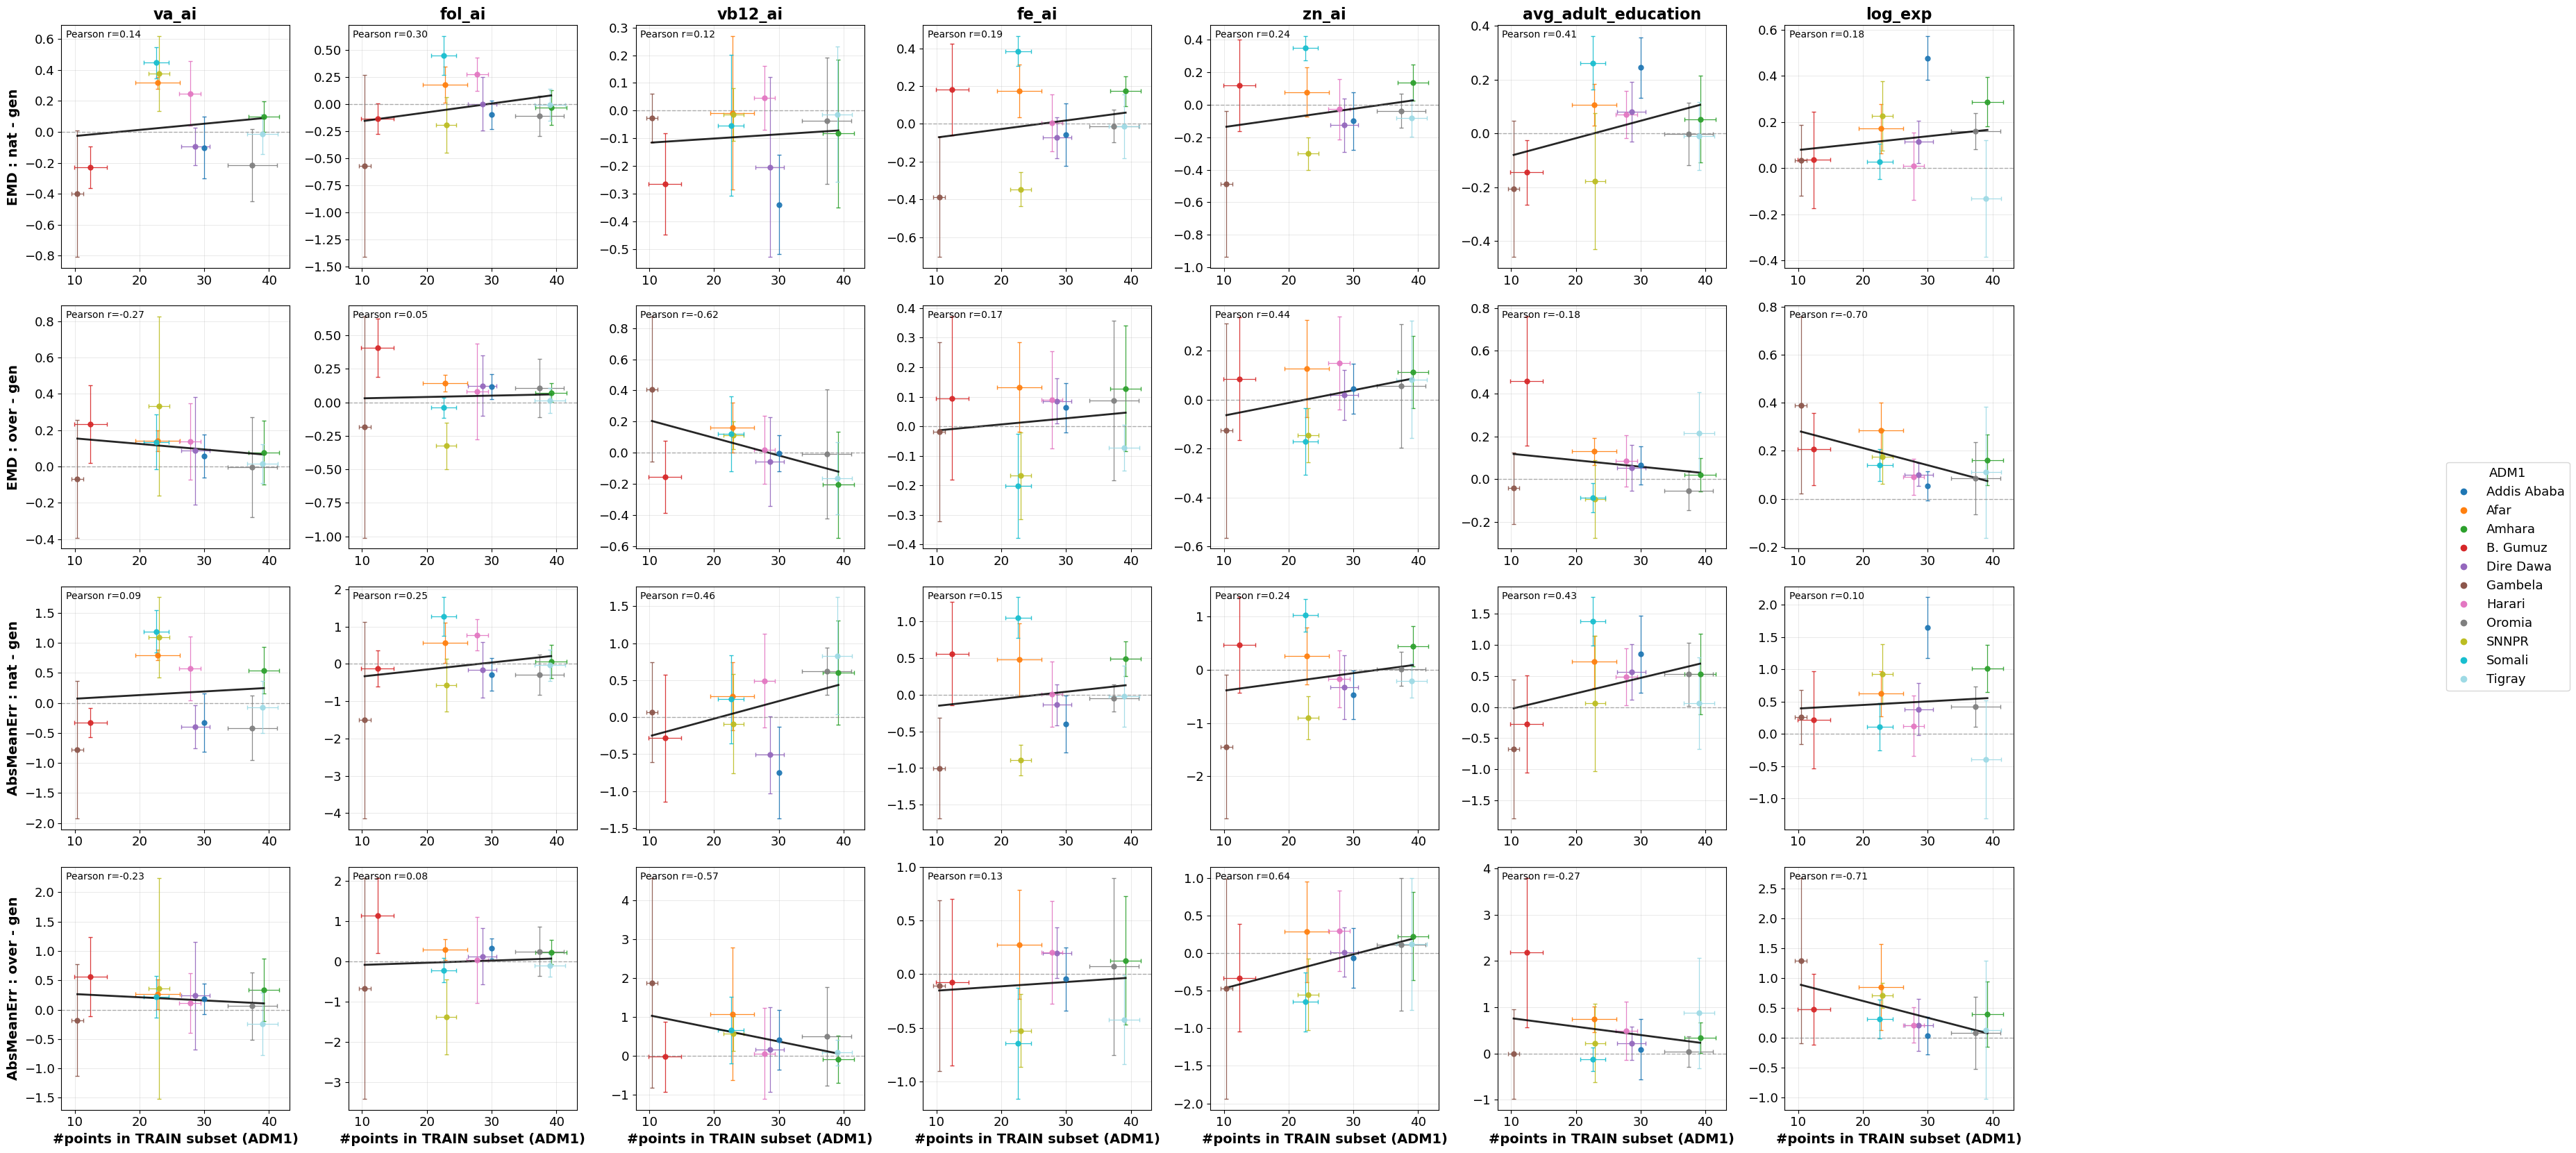

In [48]:
# Cell — correlations grid with IMPROVEMENT on y and TRAIN COUNT (seed-dependent) on x,
# with BOTH xerr (std of train counts across seeds) and yerr (std of improvements across seeds)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------
# 0) Specs: 4 rows = (2 baselines)×(2 metrics), cols = targets
# -------------------------
row_specs = [
    ("emd_nat",        "emd_gen",        "EMD : nat - gen"),
    ("emd_over",       "emd_gen",        "EMD : over - gen"),
    ("absmeanerr_nat", "absmeanerr_gen", "AbsMeanErr : nat - gen"),
    ("absmeanerr_over","absmeanerr_gen", "AbsMeanErr : over - gen"),
]

# -------------------------
# 1) Build a robust ADM1 key + display label
# -------------------------
def _norm_key(x):
    x = str(x)
    if "norm_place" in globals():
        x = norm_place(x)
    return x

# choose a region display column in metrics_df (for legend)
region_disp_col = "adm1_name" if ("adm1_name" in metrics_df.columns and not metrics_df["adm1_name"].isna().all()) else "adm1_code"

m0 = metrics_df.copy()
m0["_region_disp"] = m0[region_disp_col].astype(str)
m0["_region_key"]  = m0["_region_disp"].apply(_norm_key)

regions = sorted(m0["_region_disp"].dropna().astype(str).unique().tolist())
cmap = plt.get_cmap("tab20", max(len(regions), 1))
region2color = {r: cmap(i) for i, r in enumerate(regions)}

# -------------------------
# 2) TRAIN COUNT per seed per ADM1  -> mean/std across seeds  (this gives xerr!)
# -------------------------
train_counts = []
for seed in SEEDS:
    trn = pd.read_csv(path_train_scaled(seed))

    # pick a column to label adm1 in the train set
    if "ADM1_NAME_COL" in globals() and ADM1_NAME_COL in trn.columns:
        trn["_region_disp"] = trn[ADM1_NAME_COL].astype(str)
    elif "ADM1_COL" in globals() and ADM1_COL in trn.columns:
        trn["_region_disp"] = trn[ADM1_COL].astype(str)
    elif region_disp_col in trn.columns:
        trn["_region_disp"] = trn[region_disp_col].astype(str)
    else:
        raise KeyError(f"Can't find an ADM1 column in train file for seed={seed}. Columns: {list(trn.columns)}")

    trn["_region_key"] = trn["_region_disp"].apply(_norm_key)

    train_counts.append(
        trn.groupby("_region_key", dropna=False).size().rename("n_train").reset_index().assign(seed=seed)
    )

train_counts = pd.concat(train_counts, ignore_index=True)

train_agg = (
    train_counts
    .groupby("_region_key", dropna=False)
    .agg(n_train_mean=("n_train", "mean"),
         n_train_std =("n_train", "std"))
    .reset_index()
)

# -------------------------
# 3) IMPROVEMENT per seed per ADM1 per target  -> mean/std across seeds  (this gives yerr!)
# -------------------------
m = m0.merge(train_counts, on=["_region_key", "seed"], how="left")  # align by seed for proper x/y pairing per seed

for base, gen, _ in row_specs:
    m[f"imp_{base}"] = m[base] - m[gen]

# aggregate across seeds
agg_dict = {}
for base, _, _ in row_specs:
    agg_dict[f"imp_{base}_mean"] = (f"imp_{base}", "mean")
    agg_dict[f"imp_{base}_std"]  = (f"imp_{base}", "std")

agg = (
    m.groupby(["_region_key", "_region_disp", "target"], dropna=False)
     .agg(
         n_train_mean=("n_train", "mean"),
         n_train_std =("n_train", "std"),
         **agg_dict
     )
     .reset_index()
)

# -------------------------
# 4) Plot
# -------------------------
targets = list(target_cols) if "target_cols" in globals() else sorted(agg["target"].dropna().unique().tolist())
ncols, nrows = len(targets), len(row_specs)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.0*ncols, 4.2*nrows), sharex=False, sharey=False)
if ncols == 1:
    axes = axes.reshape(nrows, 1)

for c, t in enumerate(targets):
    a = agg.loc[agg["target"] == t].copy()

    for r, (base, gen, row_title) in enumerate(row_specs):
        ax = axes[r, c]
        ymean_col = f"imp_{base}_mean"
        ystd_col  = f"imp_{base}_std"

        # points with xerr and yerr
        for reg in regions:
            sub = a.loc[a["_region_disp"].astype(str) == str(reg)]
            if sub.empty:
                continue

            x = sub["n_train_mean"].iloc[0]
            y = sub[ymean_col].iloc[0]
            if not (pd.notna(x) and pd.notna(y)):
                continue
            x = float(x); y = float(y)
            if not (np.isfinite(x) and np.isfinite(y)):
                continue

            xerr = sub["n_train_std"].iloc[0]
            yerr = sub[ystd_col].iloc[0]
            xerr = 0.0 if (pd.isna(xerr) or not np.isfinite(float(xerr))) else float(xerr)
            yerr = 0.0 if (pd.isna(yerr) or not np.isfinite(float(yerr))) else float(yerr)

            ax.errorbar(
                x, y,
                xerr=xerr, yerr=yerr,
                fmt="o", markersize=5,
                elinewidth=0.9, capsize=2,
                color=region2color[reg],
                ecolor=region2color[reg],
                alpha=0.9,
            )

        # regression + Pearson r on region means
        xs = a["n_train_mean"].to_numpy(dtype=float)
        ys = a[ymean_col].to_numpy(dtype=float)
        msk = np.isfinite(xs) & np.isfinite(ys)
        xs2, ys2 = xs[msk], ys[msk]

        if len(xs2) >= 2:
            slope, intercept = np.polyfit(xs2, ys2, 1)
            xg = np.linspace(xs2.min(), xs2.max(), 100)
            ax.plot(xg, slope*xg + intercept, linewidth=2.0, color="black", alpha=0.85)

            r_pearson = np.corrcoef(xs2, ys2)[0, 1]
            ax.text(0.02, 0.98, f"Pearson r={r_pearson:.2f}", transform=ax.transAxes,
                    ha="left", va="top", fontsize=10)

        if r == 0:
            ax.set_title(t)

        if c == 0:
            ax.set_ylabel(row_title, fontsize=14, fontweight="bold")

        if r == nrows - 1:
            ax.set_xlabel("#points in TRAIN subset (ADM1)", fontsize=14, fontweight="bold")

        ax.axhline(0.0, linestyle="--", linewidth=1.0, color="gray", alpha=0.6)
        ax.grid(True, linewidth=0.4, alpha=0.5)

# legend outside
handles = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=6, color=region2color[reg], label=reg)
    for reg in regions
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5), title="ADM1", fontsize=13)

plt.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
plt.show()